# Students at Risk: Mental Health & Burnout

This is machine Learning Algortim

In [157]:
from sklearn.inspection import DecisionBoundaryDisplay
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

(1470, 31)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   

   DistanceFromHome  Education EducationField  EnvironmentSatisfaction  \
0                 1          2  Life Sciences                        2   
1                 8          1  Life Sciences                        3   
2                 2          2          Other                        4   
3                 3          4  Life Sciences                        4   
4                 2       

C:\Users\Abdullahi Mahamud\AppData\Local\Temp\ipykernel_31644\1508136062.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


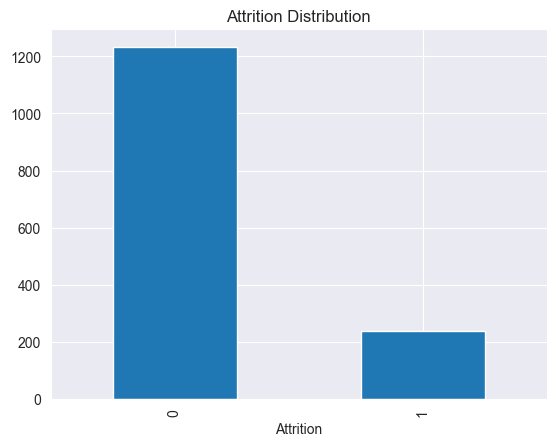

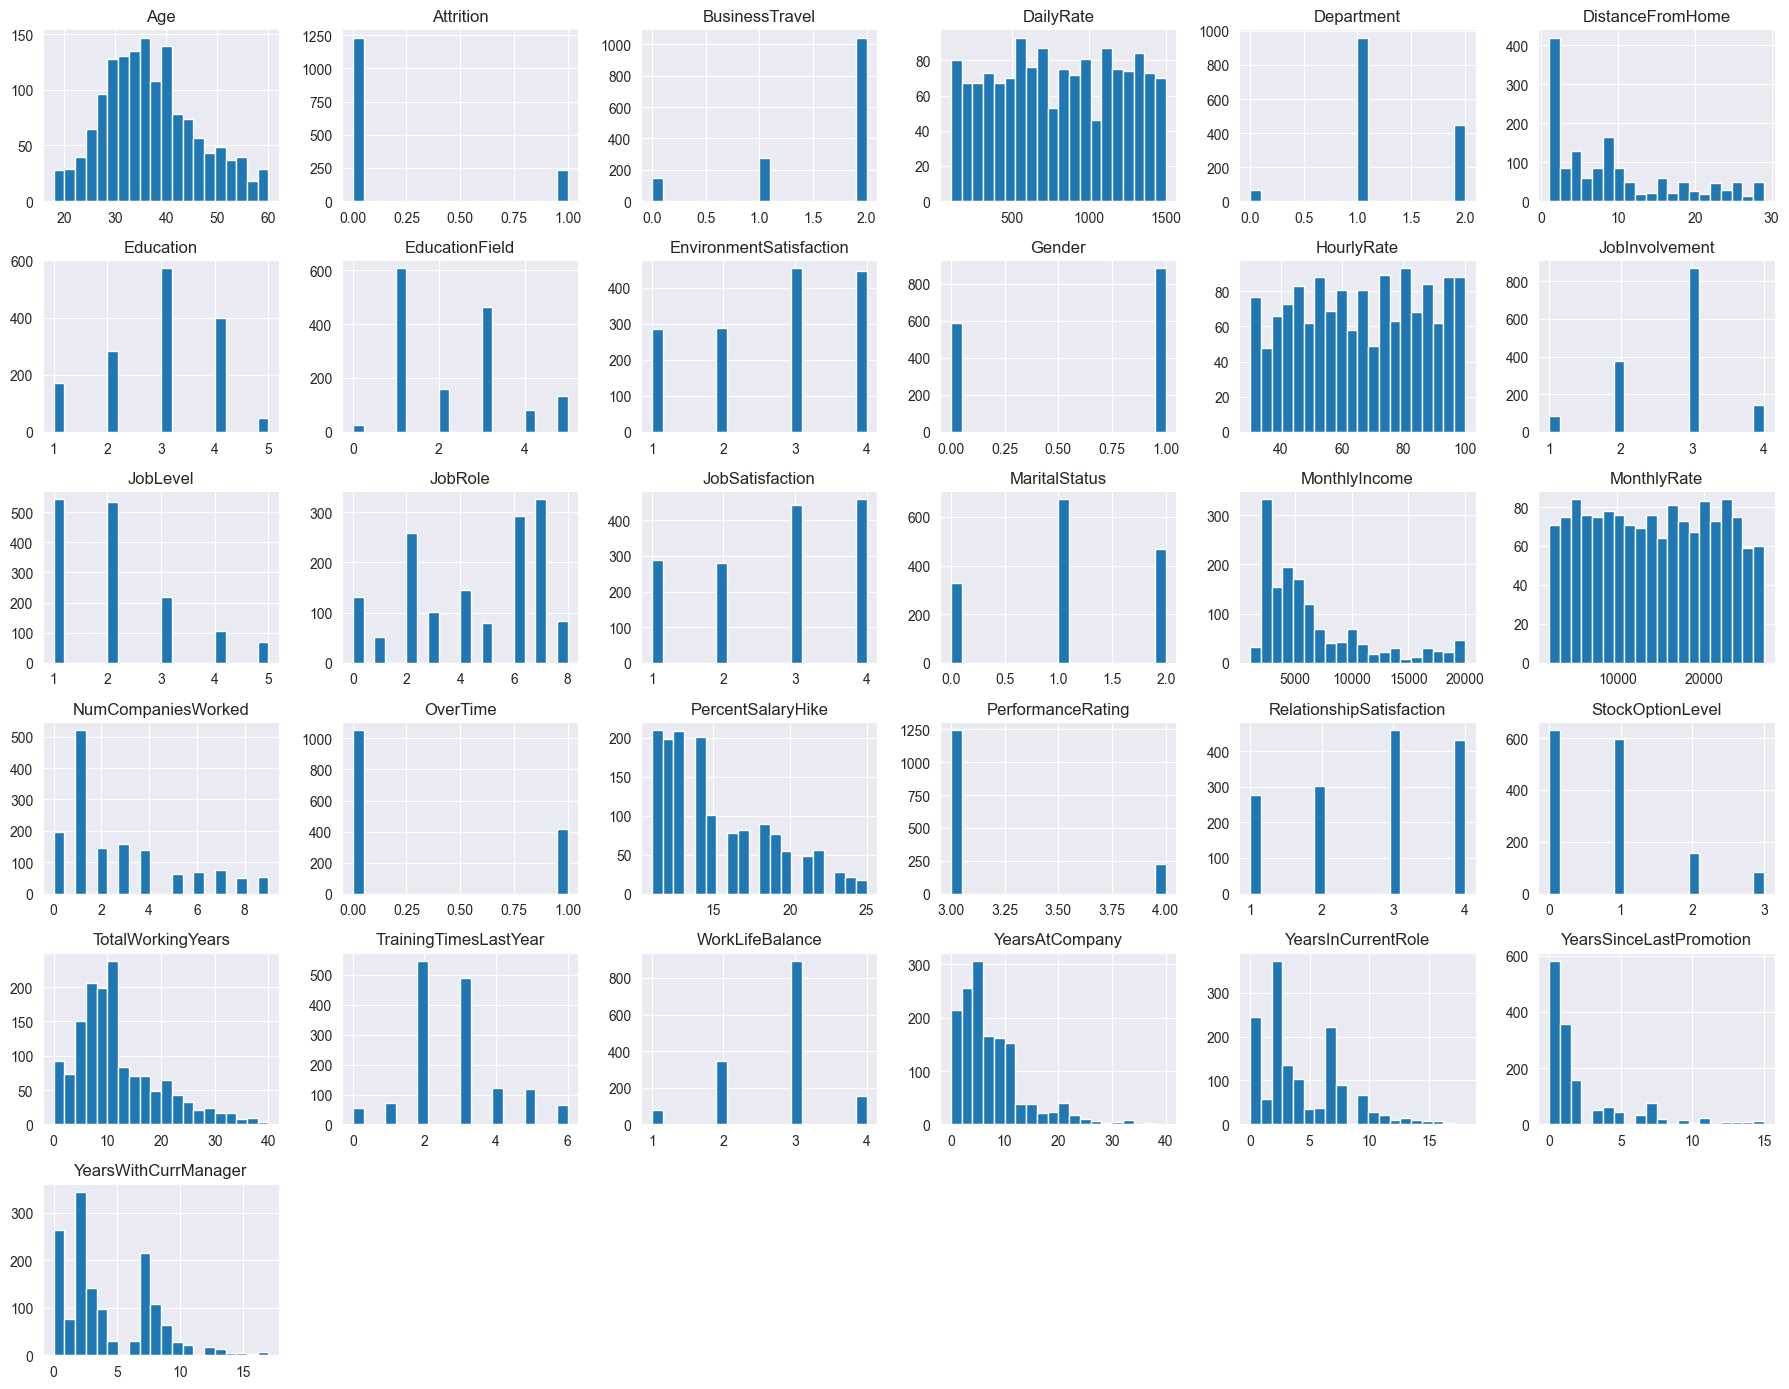

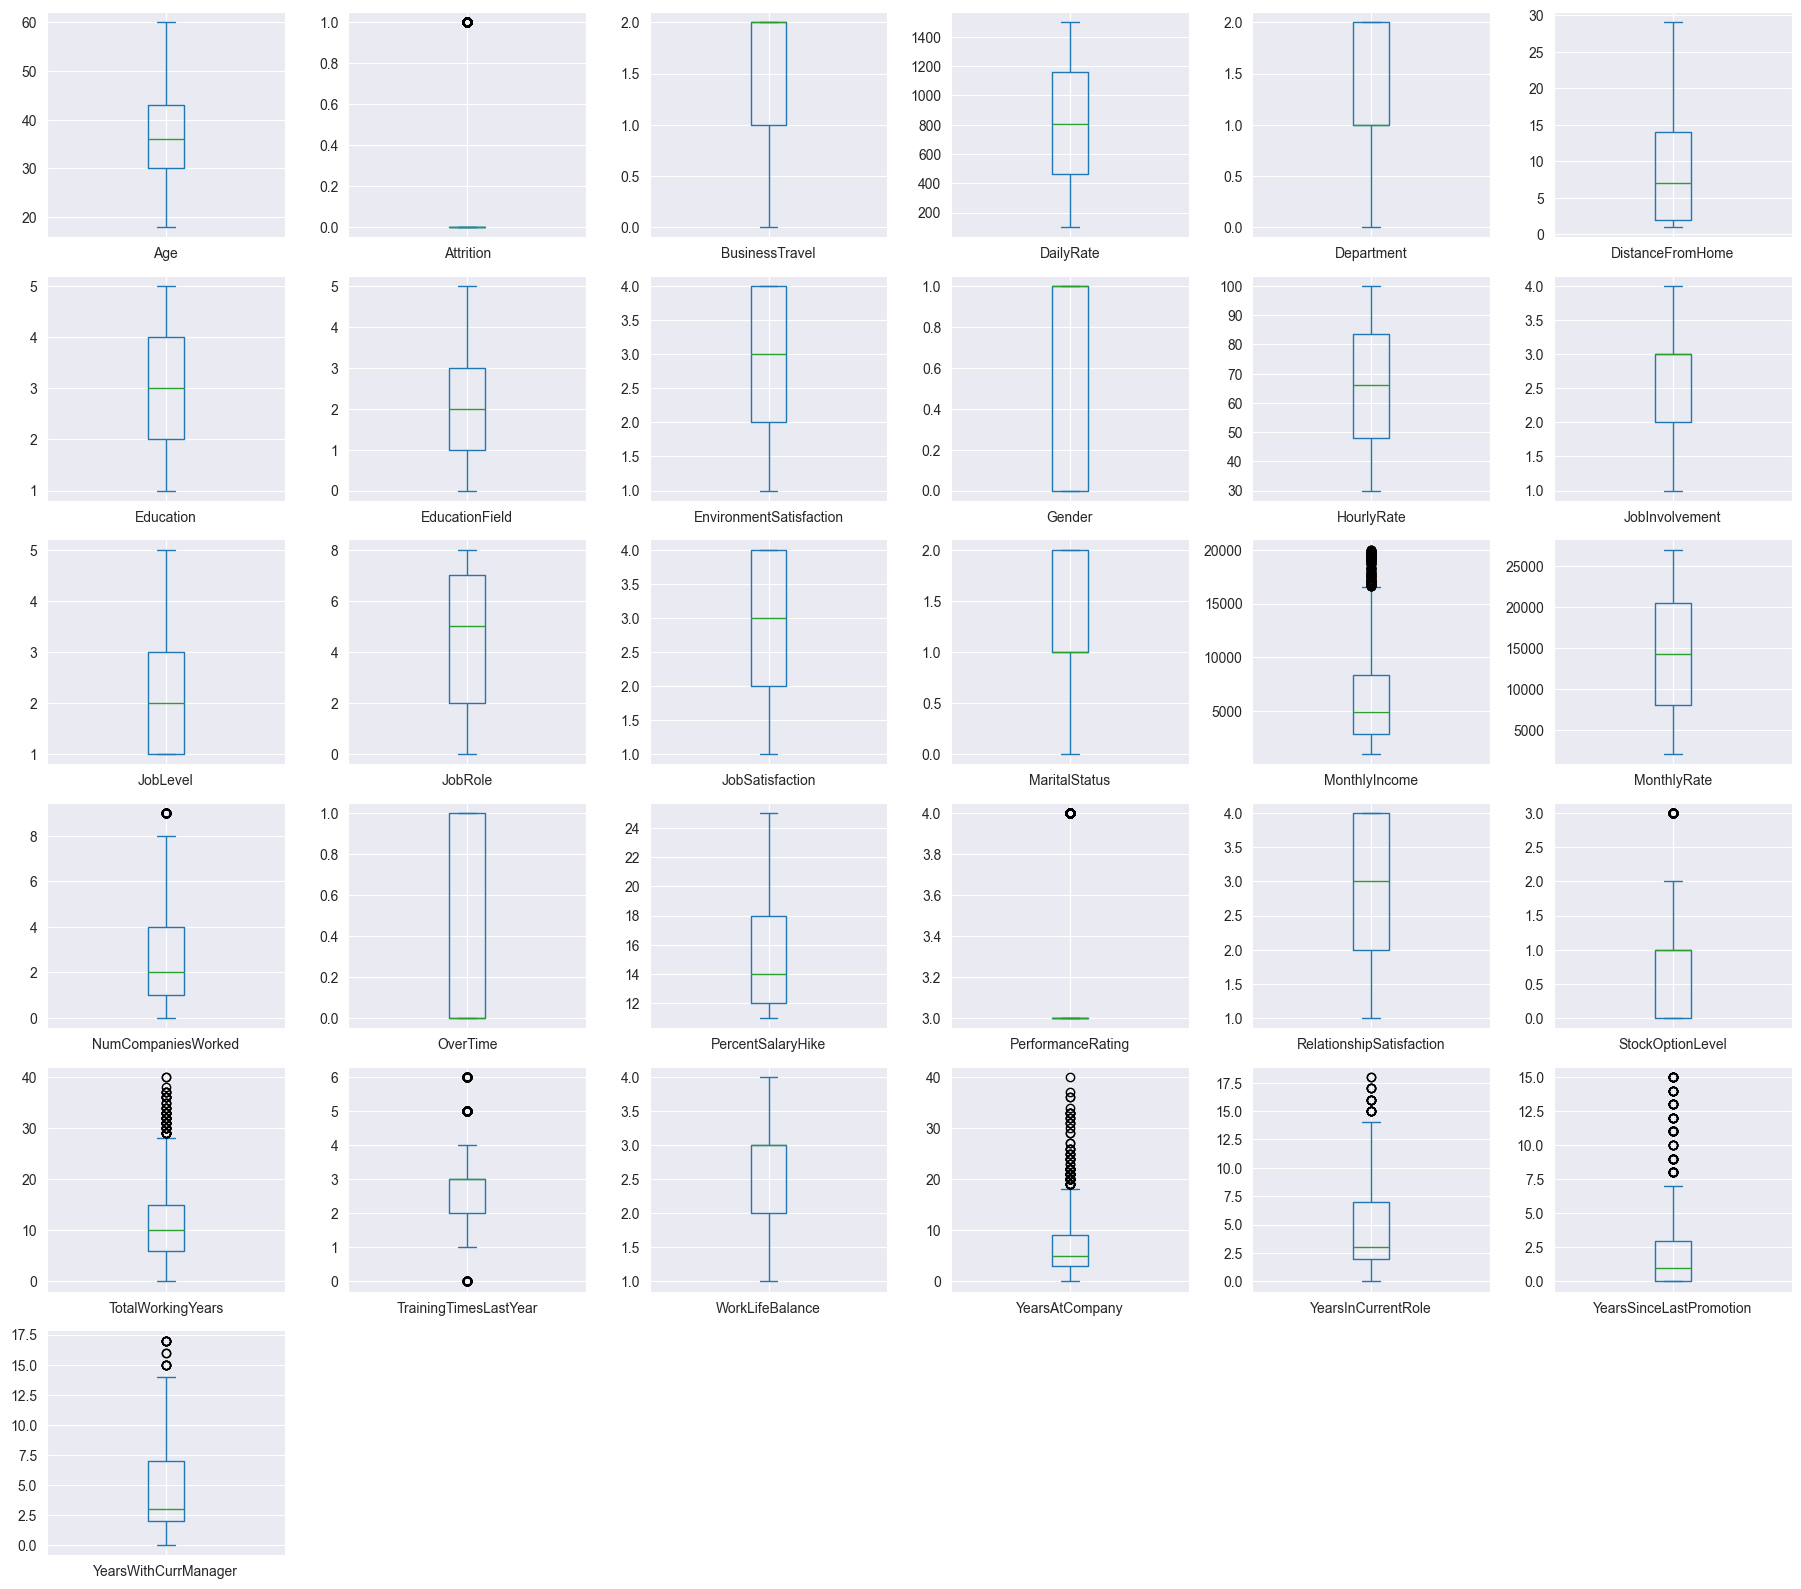

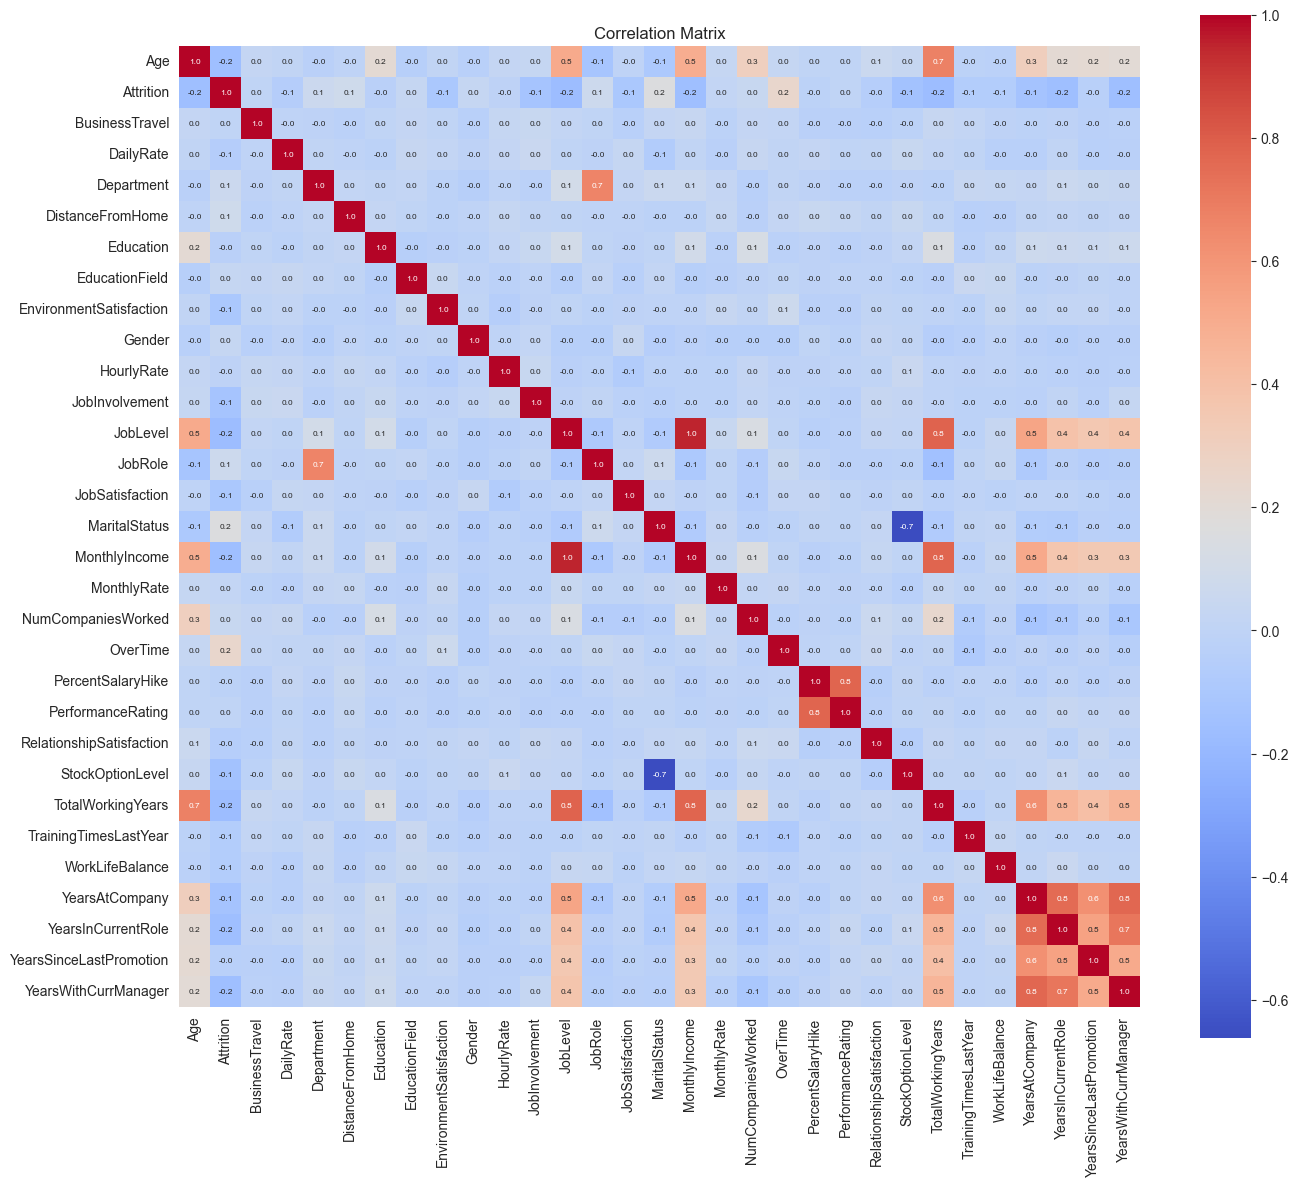

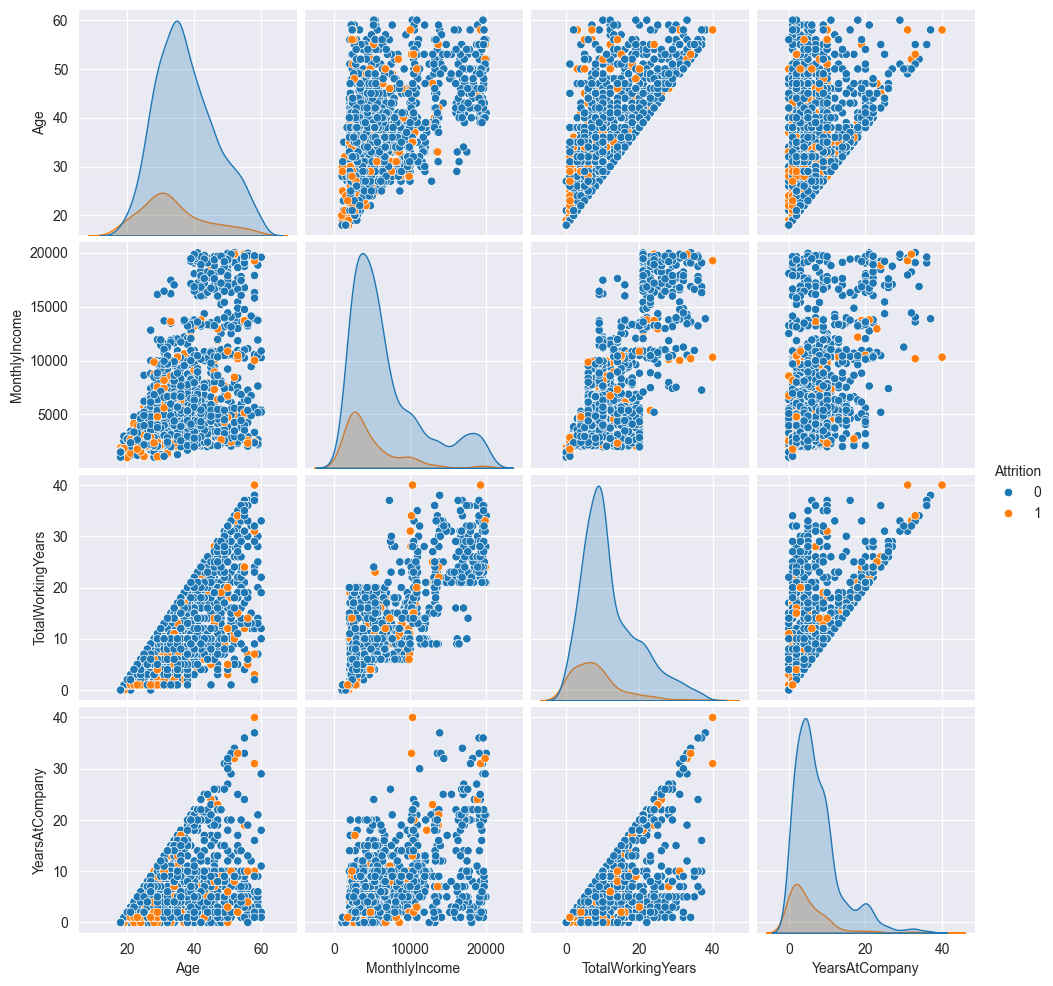

Done. Saved HR_Analytics_cleaned.csv


In [165]:
df = pd.read_csv('HR_Analytics.csv')
df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], inplace=True)

  # Basic info
print(df.shape)
print(df.head(7))
print(df.info())
print(df.describe().T)

  # Missing & duplicates
print("Missing:\n", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

  # Encode categoricals
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])
  # Class balance
print(df['Attrition'].value_counts())
df['Attrition'].value_counts().plot(kind='bar')
plt.title('Attrition Distribution')
plt.show()

  # Histograms
df.hist(figsize=(18, 14), bins=20)
plt.tight_layout()
plt.show()

  # Boxplots
df.plot(kind='box', subplots=True, layout=(6, 6), figsize=(18, 16))
plt.tight_layout()
plt.show()

  # Correlation
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(), annot=True, fmt='.1f', cmap='coolwarm', square=True, annot_kws={'size': 6})
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

  # Pairplot (key features)
sns.pairplot(df[['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'Attrition']], hue='Attrition')
plt.show()

  # Drop correlated feature & save
df.drop(columns=['YearsWithCurrManager'], inplace=True)
df.to_csv('HR_Analytics_cleaned.csv', index=False)
print("Done. Saved HR_Analytics_cleaned.csv")


Training: 1029 | Test: 441
Train classes:
Attrition
0    853
1    176
Name: count, dtype: int64
Test classes:
Attrition
0    380
1     61
Name: count, dtype: int64

=== RANDOM FOREST ===

Experiment 1: {'n_estimators': 50, 'max_depth': 5}
  Train: 0.8960 | Test: 0.8186 | Overfit: Yes
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       380
           1       0.35      0.36      0.35        61

    accuracy                           0.82       441
   macro avg       0.62      0.63      0.62       441
weighted avg       0.82      0.82      0.82       441



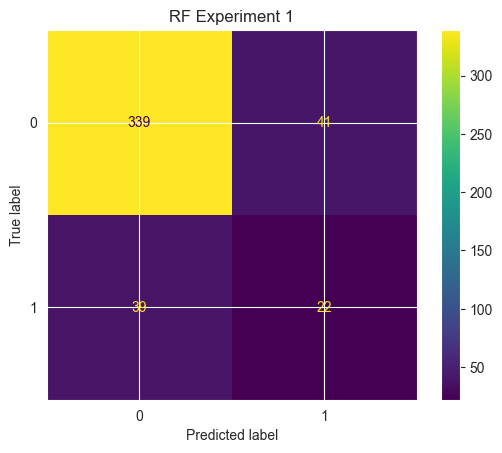


Experiment 2: {'n_estimators': 100, 'max_depth': 10}
  Train: 0.9971 | Test: 0.8617 | Overfit: Yes
              precision    recall  f1-score   support

           0       0.87      0.99      0.92       380
           1       0.50      0.08      0.14        61

    accuracy                           0.86       441
   macro avg       0.69      0.53      0.53       441
weighted avg       0.82      0.86      0.82       441



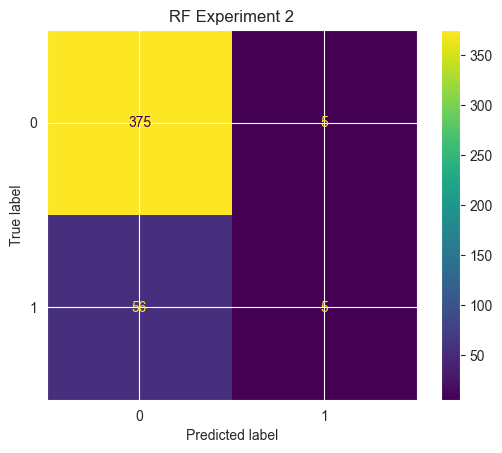


Experiment 3: {'n_estimators': 200, 'max_depth': None}
  Train: 1.0000 | Test: 0.8662 | Overfit: Yes
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       380
           1       0.62      0.08      0.14        61

    accuracy                           0.87       441
   macro avg       0.75      0.54      0.54       441
weighted avg       0.84      0.87      0.82       441



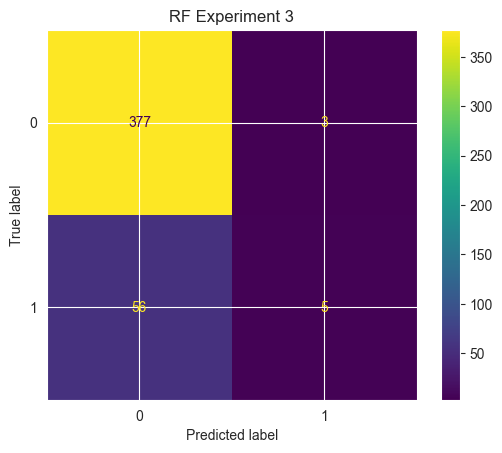


=== DECISION TREE ===

Experiment 1: {'max_depth': 3}
  Train: 0.8008 | Test: 0.8050 | Overfit: No
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       380
           1       0.35      0.46      0.39        61

    accuracy                           0.80       441
   macro avg       0.63      0.66      0.64       441
weighted avg       0.83      0.80      0.82       441



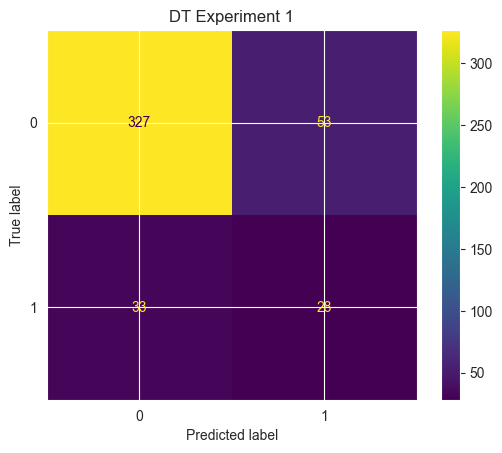


Experiment 2: {'max_depth': 5}
  Train: 0.8416 | Test: 0.7596 | Overfit: Yes
              precision    recall  f1-score   support

           0       0.92      0.79      0.85       380
           1       0.30      0.56      0.39        61

    accuracy                           0.76       441
   macro avg       0.61      0.67      0.62       441
weighted avg       0.83      0.76      0.79       441



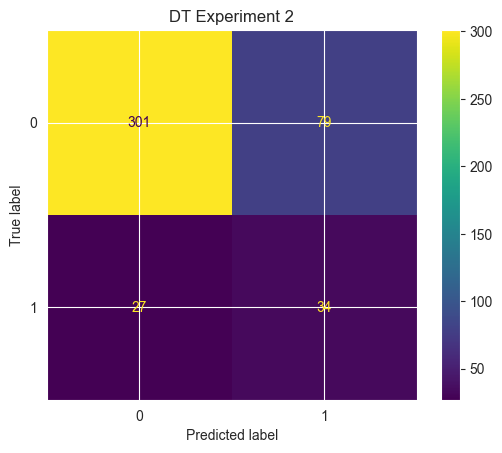


Experiment 3: {'max_depth': 10}
  Train: 0.9767 | Test: 0.7710 | Overfit: Yes
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       380
           1       0.24      0.30      0.26        61

    accuracy                           0.77       441
   macro avg       0.56      0.57      0.56       441
weighted avg       0.79      0.77      0.78       441



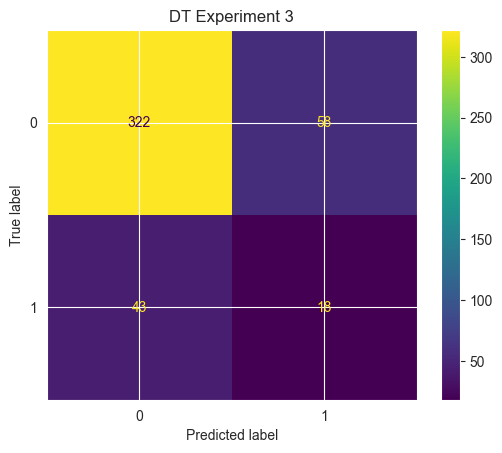

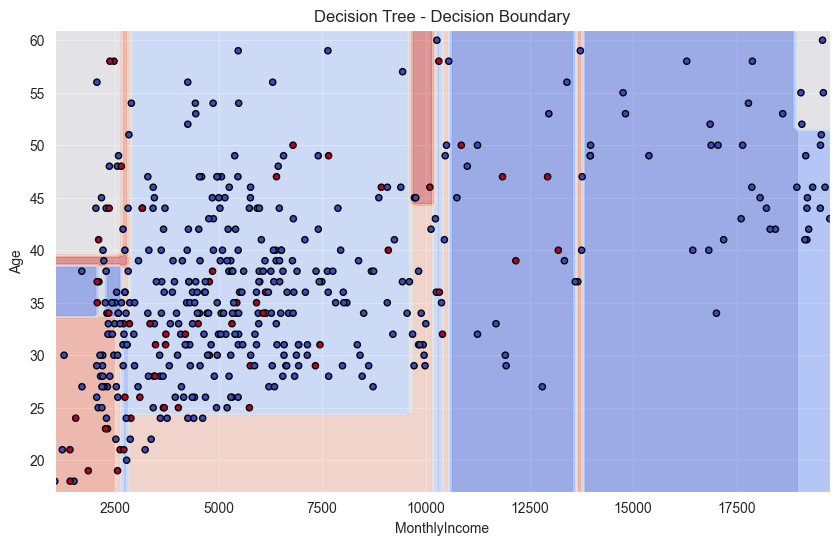

In [166]:
from sklearn.tree import DecisionTreeClassifier
df = pd.read_csv('HR_Analytics_cleaned.csv')
X = df.drop(columns=['Attrition'])
y = df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train classes:\n{y_train.value_counts()}")
print(f"Test classes:\n{y_test.value_counts()}")

  # === Random Forest (3 experiments) ===
print("\n=== RANDOM FOREST ===")
rf_configs = [
      {'n_estimators': 50, 'max_depth': 5},
      {'n_estimators': 100, 'max_depth': 10},
      {'n_estimators': 200, 'max_depth': None},
  ]
for i, params in enumerate(rf_configs, 1):
      rf = RandomForestClassifier(**params, random_state=42, class_weight='balanced')
      rf.fit(X_train, y_train)
      train_acc = accuracy_score(y_train, rf.predict(X_train))
      test_acc = accuracy_score(y_test, rf.predict(X_test))
      print(f"\nExperiment {i}: {params}")
      print(f"  Train: {train_acc:.4f} | Test: {test_acc:.4f} | Overfit: {'Yes' if train_acc - test_acc > 0.05 else
'No'}")
      print(classification_report(y_test, rf.predict(X_test)))
      ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
      plt.title(f'RF Experiment {i}')
      plt.show()

  # === Decision Tree (3 experiments) ===
print("\n=== DECISION TREE ===")
dt_configs = [
      {'max_depth': 3},
      {'max_depth': 5},
      {'max_depth': 10},
  ]
for i, params in enumerate(dt_configs, 1):
      dt = DecisionTreeClassifier(**params, random_state=42, class_weight='balanced')
      dt.fit(X_train, y_train)
      train_acc = accuracy_score(y_train, dt.predict(X_train))
      test_acc = accuracy_score(y_test, dt.predict(X_test))
      print(f"\nExperiment {i}: {params}")
      print(f"  Train: {train_acc:.4f} | Test: {test_acc:.4f} | Overfit: {'Yes' if train_acc - test_acc > 0.05 else
'No'}")
      print(classification_report(y_test, dt.predict(X_test)))
      ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test)
      plt.title(f'DT Experiment {i}')
      plt.show()

  # === Decision Boundary (bonus plot) ===
X_train_2d = X_train[['MonthlyIncome', 'Age']]
X_test_2d = X_test[['MonthlyIncome', 'Age']]
dt2 = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt2.fit(X_train_2d, y_train)
fig, ax = plt.subplots(figsize=(10, 6))
DecisionBoundaryDisplay.from_estimator(dt2, X_test_2d, ax=ax, cmap='coolwarm', alpha=0.5)
ax.scatter(X_test_2d['MonthlyIncome'], X_test_2d['Age'], c=y_test, cmap='coolwarm', edgecolors='k', s=20)
ax.set_xlabel('MonthlyIncome')
ax.set_ylabel('Age')
ax.set_title('Decision Tree - Decision Boundary')
plt.show()


=== K-MEANS ===
k=2 | Silhouette Score: 0.4662
k=3 | Silhouette Score: 0.4930
k=4 | Silhouette Score: 0.4436
k=5 | Silhouette Score: 0.4347
k=6 | Silhouette Score: 0.3872


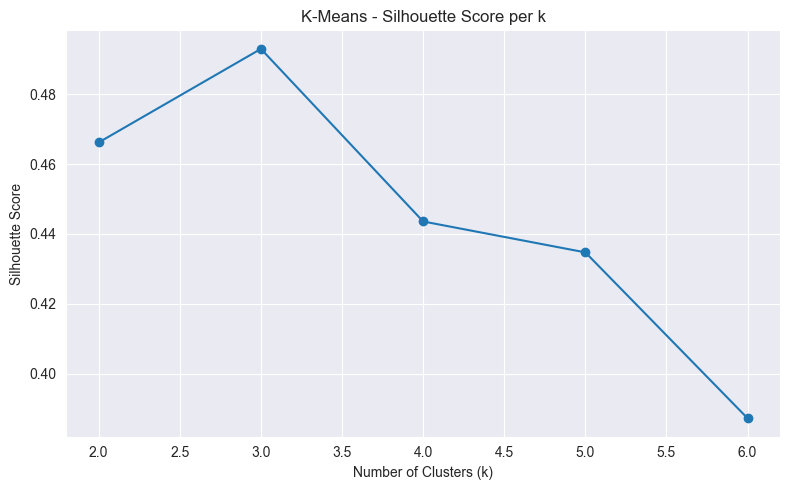


Best k: 3 (score: 0.4930)


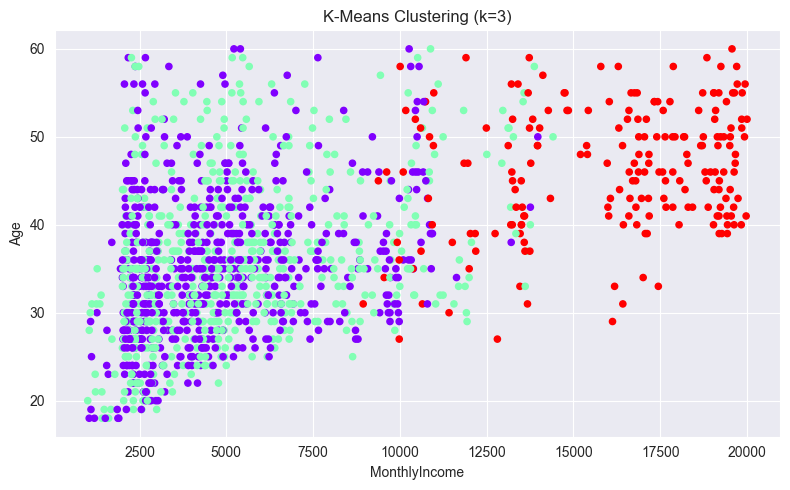


=== HIERARCHICAL CLUSTERING ===


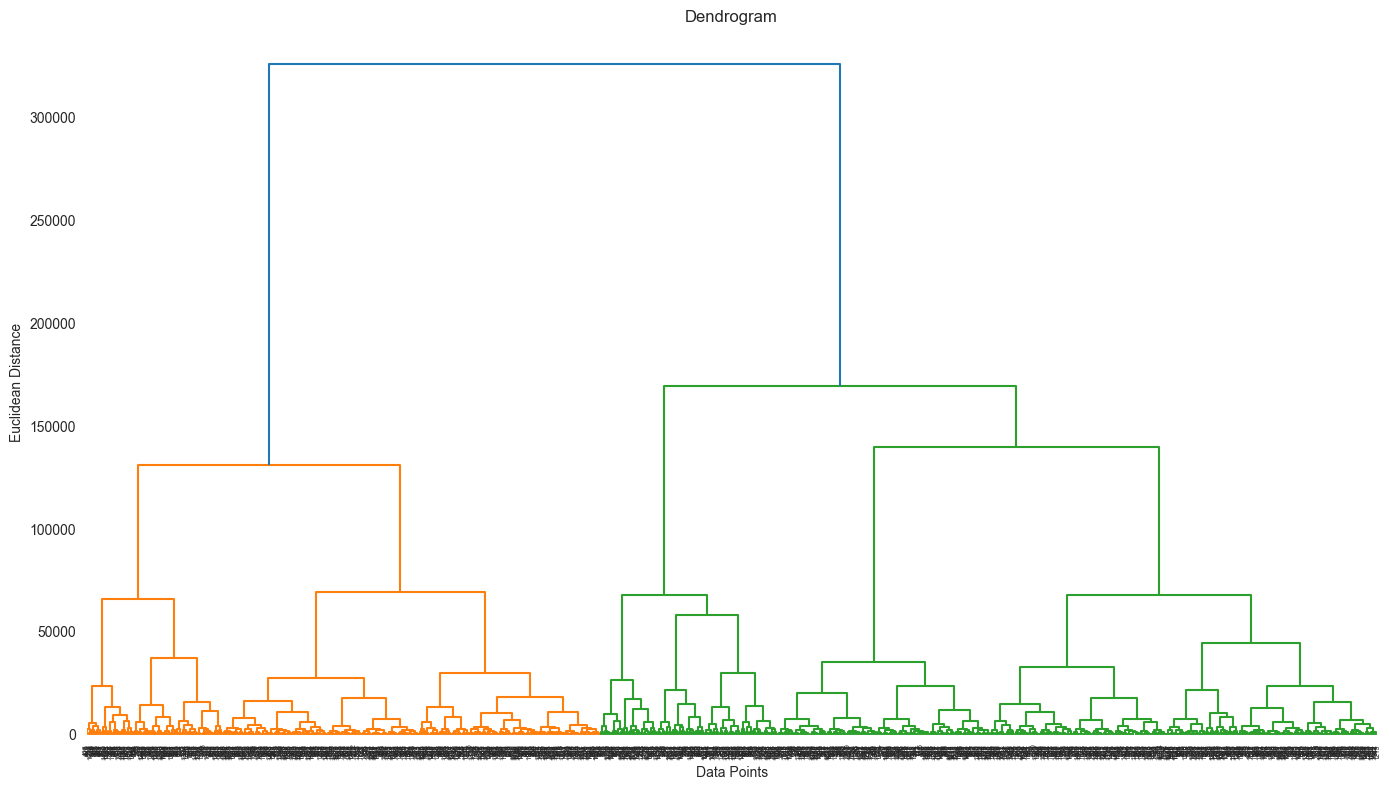


Experiment 1: {'n_clusters': 2, 'linkage': 'ward'}
  Silhouette Score: 0.4387


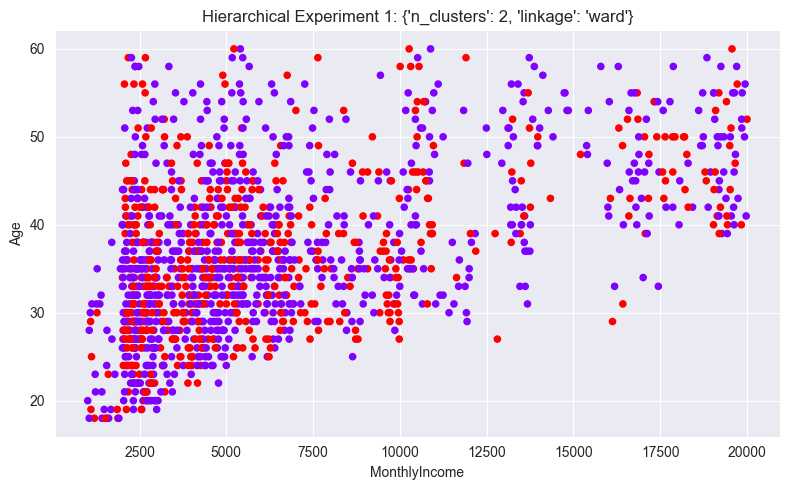


Experiment 2: {'n_clusters': 3, 'linkage': 'ward'}
  Silhouette Score: 0.4109


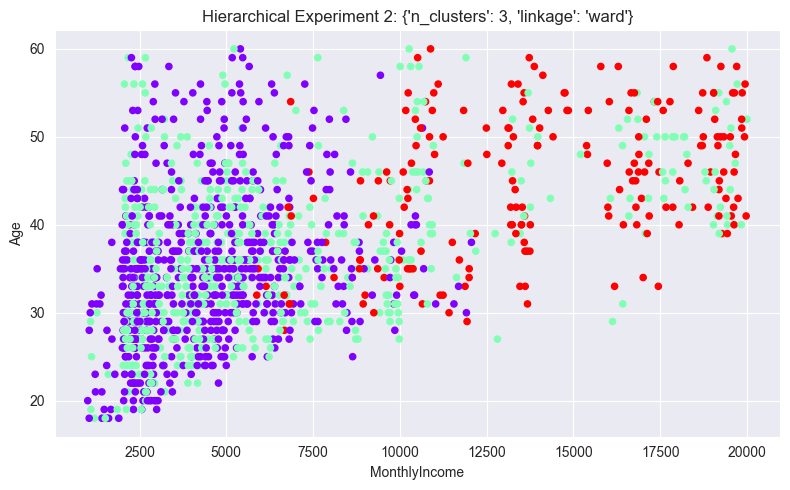


Experiment 3: {'n_clusters': 3, 'linkage': 'complete'}
  Silhouette Score: 0.4378


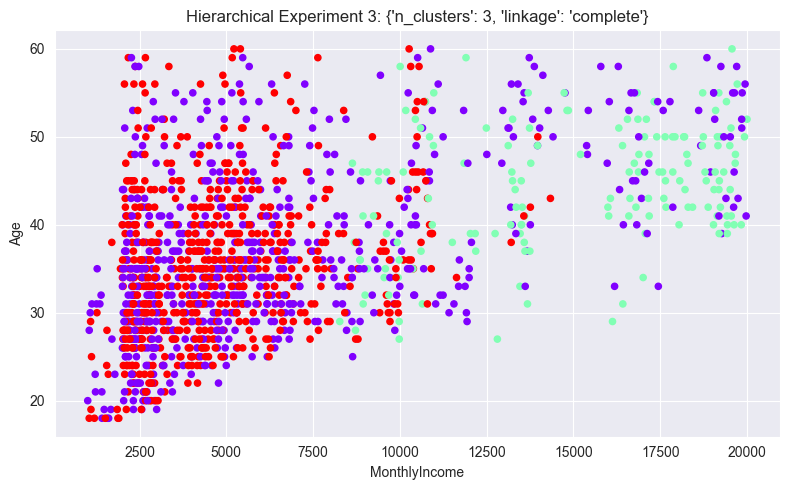

In [172]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

df = pd.read_csv('HR_Analytics_cleaned.csv')
X = df.drop(columns=['Attrition'])

# === K-Means (5 different k values) ===
print("=== K-MEANS ===")
k_values = [2, 3, 4, 5, 6]
silhouette_scores = []

for k in k_values:
      kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
      labels = kmeans.fit_predict(X)
      score = silhouette_score(X, labels)
      silhouette_scores.append(score)
      print(f"k={k} | Silhouette Score: {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('K-Means - Silhouette Score per k')
plt.tight_layout()
plt.show()

  # Best k
best_k = k_values[np.argmax(silhouette_scores)]
print(f"\nBest k: {best_k} (score: {max(silhouette_scores):.4f})")

  # Plot best k clusters
kmeans_best = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
labels_best = kmeans_best.fit_predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X['MonthlyIncome'], X['Age'], c=labels_best, cmap='rainbow', s=20)
plt.xlabel('MonthlyIncome')
plt.ylabel('Age')
plt.title(f'K-Means Clustering (k={best_k})')
plt.tight_layout()
plt.show()

 # === Hierarchical Clustering (3 experiments) ===
print("\n=== HIERARCHICAL CLUSTERING ===")
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as shc

  # Dendrogram
plt.figure(figsize=(14, 8))
plt.title('Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
dendrogram = shc.dendrogram(shc.linkage(X, method='ward'))
plt.tight_layout()
plt.show()

hc_configs = [
      {'n_clusters': 2, 'linkage': 'ward'},
      {'n_clusters': 3, 'linkage': 'ward'},
      {'n_clusters': 3, 'linkage': 'complete'},
  ]

for i, params in enumerate(hc_configs, 1):
      hc = AgglomerativeClustering(**params)
      labels = hc.fit_predict(X)
      score = silhouette_score(X, labels)
      print(f"\nExperiment {i}: {params}")
      print(f"  Silhouette Score: {score:.4f}")

      plt.figure(figsize=(8, 5))
      plt.scatter(X['MonthlyIncome'], X['Age'], c=labels, cmap='rainbow', s=20)
      plt.xlabel('MonthlyIncome')
      plt.ylabel('Age')
      plt.title(f'Hierarchical Experiment {i}: {params}')
      plt.tight_layout()
      plt.show()
